In [1]:
import pandas as pd
df = pd.read_excel("Desktop/pycharm/Dataset for Data Analytics decolab_cleaned.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200112,2023-01-01,C81366,Monitor,1,410.60,423 Main St,Online,Cancelled,TRK17062206,2,WINTER15,Referral,410.60
1,ORD200236,2023-01-01,C14847,Monitor,1,318.81,562 Main St,Debit Card,Pending,TRK39663243,3,WINTER15,Email,318.81
2,ORD200848,2023-01-01,C54675,Chair,2,645.85,634 Main St,Online,Shipped,TRK18049633,5,NaN,Referral,1291.70
3,ORD200645,2023-01-02,C82990,Laptop,2,150.05,727 Main St,Credit Card,Cancelled,TRK68574801,4,SAVE10,Facebook,300.10
4,ORD200373,2023-01-02,C60178,Laptop,3,341.15,969 Main St,Cash,Pending,TRK84505143,4,FREESHIP,Instagram,1023.45


In [2]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [3]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [4]:
df['CouponCode']=df['CouponCode'].fillna('None')
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [5]:
df.drop(columns='Date').describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [6]:
df.drop(columns='Date').describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


Quantity - mean 2.95, median 3.0 are fairly balanced, no skew. Most orders are for 1 - 5 items, spread evenly
UnitPrice - mean 356.41, median 364.21 also balanced. Prices range from 11.39 to 699.93, a wide spread (high std dev of 197), meaning products vary a lot. it makes with electronics and furniture mixed together.
ItemsInCart - mean 5.49, median 5.0 are balanced, typical cart has 1 - 10 items.
TotalPrice - mean 1053.97 is noticeably higher than median 823.62 which means data is right-skewed, a handful of large orders up to 3456.40 are pulling the average up, while most orders sit lower, closer to the median. this is a classic sign of outliers

## Check for Outliers (TotalPrice and UnitPrice)

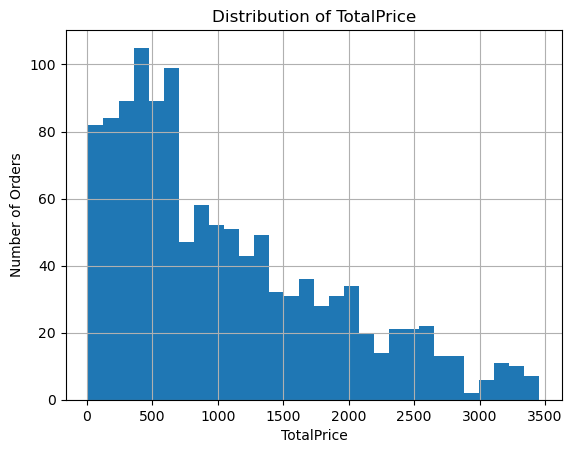

In [7]:
import matplotlib.pyplot as plt
df['TotalPrice'].hist(bins=30)
plt.title('Distribution of TotalPrice')
plt.xlabel('TotalPrice')
plt.ylabel('Number of Orders')
plt.show()

In [8]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
82,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
123,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
162,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
220,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,None,Facebook,3390.95
317,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
418,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
455,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,None,Facebook,3384.90
747,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40


All have Quantity = 5 which is the max in the dataset
All have UnitPrice above 660 (near the top of the price range)
these are legitimate large orders, high quantity of expensive items

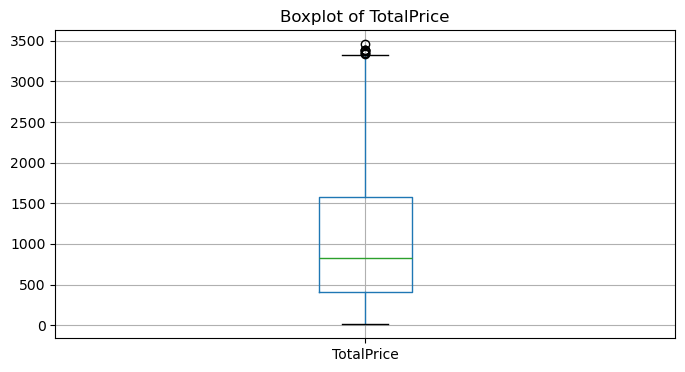

In [15]:
plt.figure(figsize=(8,4))
df.boxplot(column='TotalPrice')
plt.title('Boxplot of TotalPrice')
plt.show()

## Outliers check for UnitPrice

In [9]:
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 

outliers_price = df[(df['UnitPrice'] < lower_bound) | (df['UnitPrice'] > upper_bound)]
len(outliers_price)


0

UniitPrice has no outliers unlike TotalPrice which had 8. UnitPrice values are naturally spread out 11-700, while TotalPrice outliers came from the combination of high Quantity * high UnitPrice, not from UnitPrice alone

## Correlation Analysis

In [16]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


UnitPrice - TotalPrice: 0.717 (strong relationship) - price per item has the biggest pull on the total
Quantity - TotalPrice: 0.615 quantity matters too, just slightly less
ItemsInCart - TotalPrice: 0.393 weaker relationship, makes sense since ItemsInCart is a separate metric from the specific order's Quantity/UnitPrice
Quantity vs UnitPrice: 0.015 essentially no relationship - buying more items does not mean you are buying pricier items, which is a good sign of realistic, unbiased data

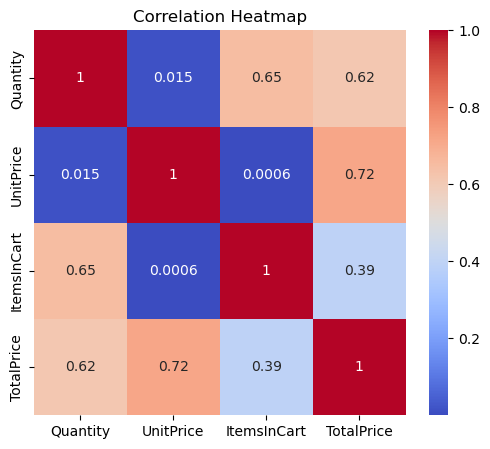

In [17]:
import seaborn as sns

plt.figure (figsize=(6,5))
sns.heatmap(df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Identify Trends - Product Distribution

In [10]:
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

No dominant Product

In [11]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

No dominant Payment type

In [12]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

No status dominates

## monthly Trend

In [13]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()
monthly_revenue

Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64

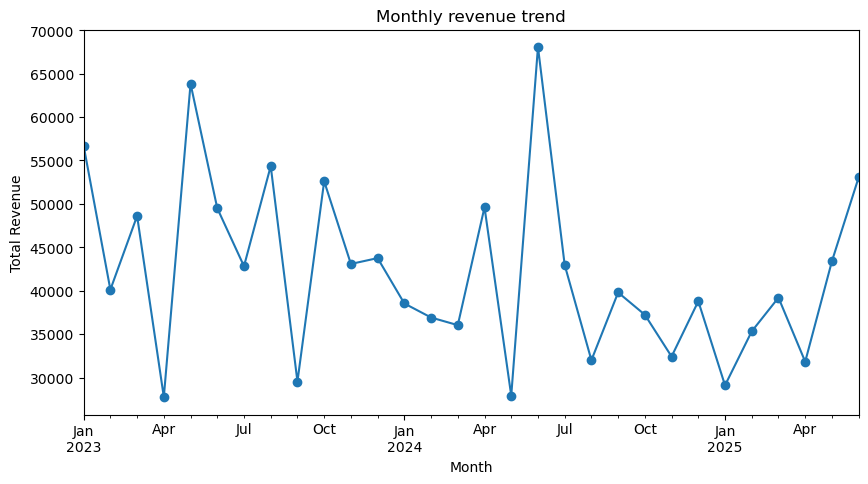

In [14]:
monthly_revenue.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly revenue trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()